In [2]:
from pysilicon.hw.dataschema import DataList, IntField
from pysilicon.utils.timing import TimingDiagram, ClkSig, SigTimingInfo

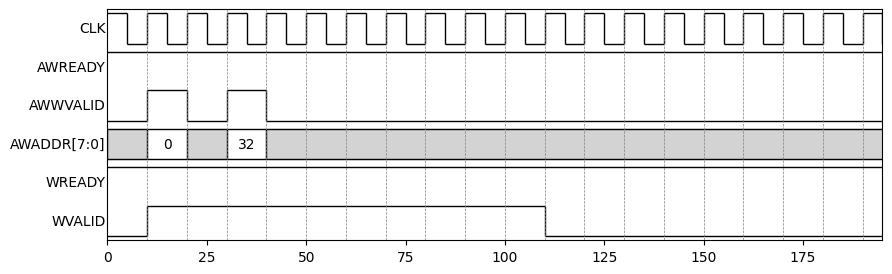

In [ ]:
# Showing two bursts
ncycles = 20
clk_period = 10
clk = ClkSig(clk_name="CLK", period=clk_period, ncycles=ncycles)
p = clk.clk_periods()


burstLen = [4, 5]  # Number of data beats in each burst
ardy = [1,3]  # Clock cycle to set addr and data ready

# Setting the address for the two requests
awvalid = SigTimingInfo(
    name= "AWWVALID",
    times = [p[0], p[ardy[0]], p[ardy[0]+1], p[ardy[1]], p[ardy[1]+1]],
    values = ['0', '1', '0', '1', '0'],
)
awready = SigTimingInfo(
    name= "AWREADY",
    times = [p[0]],
    values = ['1'],
)
awaddr = SigTimingInfo(
    name= "AWADDR[7:0]",
    times = [p[0], p[ardy[0]], p[ardy[0]+1], p[ardy[1]], p[ardy[1]+1]],
    values = ['x', '0', 'x', '32', 'x'],
)
awaddr = SigTimingInfo(
    name= "AWADDR[7:0]",
    times = [p[0], p[ardy[0]], p[ardy[0]+1], p[ardy[1]], p[ardy[1]+1]],
    values = ['x', str(burstLen[0]), 'x', str(burstLen[1]), 'x'],
)



# Setting the data
wready = SigTimingInfo(
    name= "WREADY",
    times = [p[0]],
    values = ['1'],
)
dat_st = ardy[0]
dat_end = dat_st + burstLen[0] + burstLen[1]
wvalid = SigTimingInfo(
    name= "WVALID",
    times = [p[0], p[dat_st], p[dat_end+1]],
    values = ['0', '1', '0'],
)


if 0:
    # Setting the data
    wready = SigTimingInfo(
        name= "WREADY",
        times = [p[0], p[irdy], p[idat+1]],
        values = ['0', '1', '0'],
    )
    wvalid = SigTimingInfo(
        name= "WVALID",
        times = [p[0], p[idat], p[idat+1]],
        values = ['0', '1', '0'],
    )
    wdata = SigTimingInfo(
        name= "WDATA[7:0]",
        times = [p[0], p[idat], p[idat+1]],
        values = ['0x00', '0xAB', '0xCD']
    )

    # BREADY and BVALID
    iend = max(iaddr+1, idat+1)  # Finish after last of addr or data
    bready = SigTimingInfo(
        name= "BREADY",
        times = [p[0], p[iend], p[iend+1]],
        values = ['0', '1', '0']
    )
    bvalid = SigTimingInfo(
        name= "BVALID",
        times = [p[0], p[iend+1], p[iend+2]],
        values = ['0', '1', '0'],
    )

td = TimingDiagram()
td.add_signals([clk, awready, awvalid, awaddr])
td.add_signals([wready, wvalid])
#td.add_signals([clk, wready, wvalid, wdata])
#td.add_signals([bready,bvalid])
ax = td.plot_signals(text_mode='always')
#td.add_patch(sig_name="AWADDR[7:0]", ind=1, color='lightgreen', alpha=0.5)
#td.add_patch(sig_name="WDATA[7:0]", ind=1, color='lightblue', alpha=0.5)
#ax.set_xlabel("Time [ns]")

